In [4]:
# Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [5]:
# Funkcje pomocnicze: wykres predykcji modelu, metryki oceny modelu RMSE i MAE)
# Jeśli RMSE jest dużo wyższe niż MAE, oznacza to, że model radzi sobie dobrze przez większość czasu,
# ale "wywala się" na kilku konkretnych dniach (np. przy nagłych krachach giełdowych).
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)

def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}.".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [6]:
# Wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [7]:
# Ustawiamy zbiory trenujące i testowe oraz szukamy brakujących wartości
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

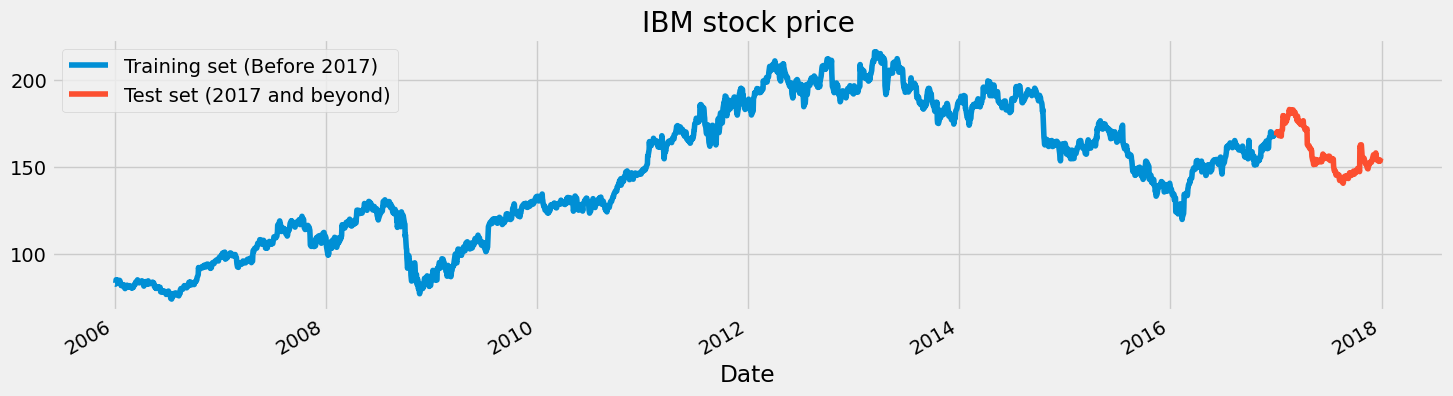

In [8]:
# Wizualizacja danych
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [9]:
# Normalizacja danych trenujących
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [10]:
# Ponieważ komórki LSTM przechowują stan pamięci długotrwałej,
# tworzymy strukturę danych z 60 krokami czasowymi i 1 wyjściem.
X_train = []
y_train = []
for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [11]:
# Przekształcanie X_train w celu zapewnienia wydajnego modelowania
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [12]:
# Architektura LSTM, sieć regresyjna, predykująca
regressor = Sequential()

# Warstwa wejściowa
regressor.add(Input(shape=(X_train.shape[1], 1)))

# Pierwsza warstwa LSTM
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))

# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))

# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))

# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100))
regressor.add(Dropout(0.2))

# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Ustawiamy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trenujemy sieć
regressor.fit(X_train, y_train, epochs=50, batch_size=32)

# Wersja z Early Stopping (do odkomentowania przy testach)
# early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
# regressor.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0357
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0119
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0084
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0069
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0059
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0045
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0025
Epoc

In [13]:
# Przygotowanie zestawu testowego
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [14]:
# Przygotowanie X_test i predykcja cen akcji
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


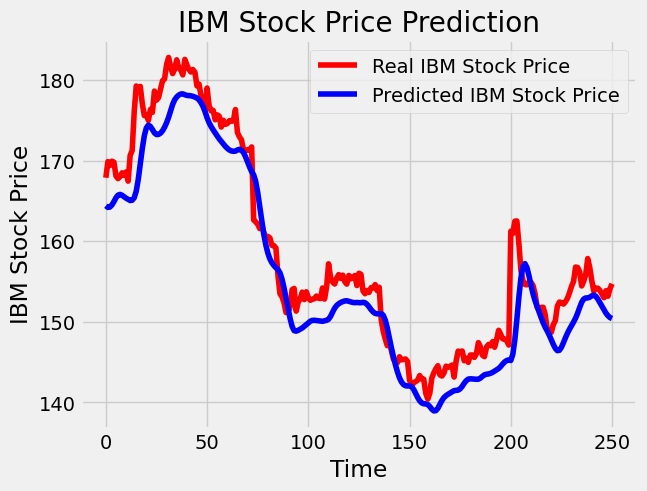

------------------------------
Błąd średniokwadratowy modelu 4.00.
------------------------------
Średni błąd bezwzględny: 3.25.
Średni błąd bezwzględny procentowy: 2.04%
------------------------------


In [15]:
# Wizualizacja wyników dla sieci LSTM
plot_predictions(test_set, predicted_stock_price)

# Ocena modelu
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

In [16]:
# Architektura z bramką GRU
regressorGRU = Sequential()

# Warstwa wejściowa
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

# Warstwy GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Warstwa wyjściowa
regressorGRU.add(Dense(units=1))

# Kompilacja
regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trening z Early Stopping
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0185
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0081
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0071
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0061
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0057
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0049
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0038
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0037
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0029
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0028
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


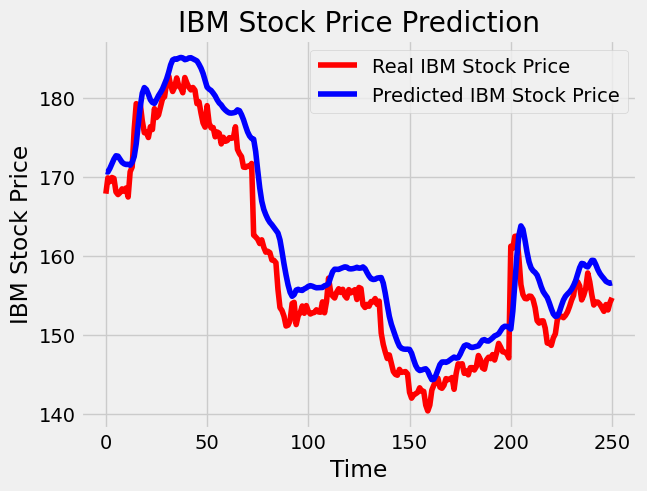

------------------------------
Błąd średniokwadratowy modelu 4.04.
------------------------------
Średni błąd bezwzględny: 3.59.
Średni błąd bezwzględny procentowy: 2.27%
------------------------------


In [17]:
# Przygotowanie danych i predykcja GRU
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

# Wizualizacja i ocena
plot_predictions(test_set, GRU_predicted_stock_price)
return_rmse(test_set, GRU_predicted_stock_price)
return_mae(test_set, GRU_predicted_stock_price)

LSTM uzyskał błąd RMSE na poziomie ok. 3.21 oraz MAE ok. 2.28.
GRU uzyskał błąd RMSE ok. 3.77 oraz MAE ok. 3.24.
W tym konkretnym przypadku model LSTM poradził sobie lepiej, wykazując mniejsze odchylenia od rzeczywistych cen.

A) Obserwacje po zmianie jednostek (z 50 na 100): Paradoksalnie, zwiększenie złożoności modelu (więcej neuronów) w tym przypadku pogorszyło wynik. Model mógł zacząć zbyt mocno dopasowywać się do szumu w danych treningowych zamiast do ogólnego trendu.